<h1><b>ACV Refrigerant Leakage Exploratory Data Analysis</b></h1>

<h4><b>Background Information</b></h4>

The ACV subsystem in NEBULA X Problem Statement 3 concerns refrigerant-leak localisation among the cars of a train. Each supplied case contains one car labelled as faulty. The required eventual output is a ranking of every car in each held-out case.

<h4><b>Objective</b></h4>

This notebook assesses data quality, telemetry compatibility, operating modes, and temperature differences that can inform later car-ranking models. Case-level labels do not identify fault onset or prove that every reading from the affected car is abnormal.

<h4><b>Project Workflow</b></h4>

The analysis inventories workbooks and labels, validates schemas and timestamps, constructs an explicit common-parameter view, examines operating context and peer differences, summarises candidate features, and documents case-level validation requirements.

<h4><b>Dataset Used</b></h4>

`PS3/02_Datasets/ACV` contains six labelled Train workbooks, `Train_Labels.csv`, and one unlabelled Test workbook. The authoritative task and rank-decay metric are documented in `PS3/03_References/ACV/ACV_Subsystem_Info_Kit.md`. Car identifiers retain the two-digit strings used in each workbook’s headers. No models or Test rankings are produced in this EDA.

<h4><b>Table of Contents</b></h4>
<ul>
  <li><a href="#section-1">Section 1: Environment Setup and Data Loading</a>
    <ul>
      <li><a href="#1-1">1.1 Libraries and Dataset Location</a></li>
      <li><a href="#1-2">1.2 Workbook Inventory and Label Loading</a></li>
    </ul>
  </li>
  <li><a href="#section-2">Section 2: Schema and Label Validation</a>
    <ul>
      <li><a href="#2-1">2.1 Car and Parameter Discovery</a></li>
      <li><a href="#2-2">2.2 Sample Values and Metadata</a></li>
    </ul>
  </li>
  <li><a href="#section-3">Section 3: Data Quality and Sampling Assessment</a>
    <ul>
      <li><a href="#3-1">3.1 Timestamp and Duplicate Audit</a></li>
      <li><a href="#3-2">3.2 Missingness and Sparse Telemetry</a></li>
    </ul>
  </li>
  <li><a href="#section-4">Section 4: Common-Parameter View and Operating Context</a>
    <ul>
      <li><a href="#4-1">4.1 Explicit Parameter Mapping</a></li>
      <li><a href="#4-2">4.2 Value Domains and Temperature Screens</a></li>
      <li><a href="#4-3">4.3 Cooling and Validity Coverage</a></li>
    </ul>
  </li>
  <li><a href="#section-5">Section 5: Temperature Behaviour Within Cases</a>
    <ul>
      <li><a href="#5-1">5.1 Contemporaneous Peer Differences</a></li>
      <li><a href="#5-2">5.2 Train Case Profiles</a></li>
      <li><a href="#5-3">5.3 Operating-Mode Confounding</a></li>
    </ul>
  </li>
  <li><a href="#section-6">Section 6: Case-and-Car Feature Exploration</a>
    <ul>
      <li><a href="#6-1">6.1 Candidate Features and Coverage</a></li>
      <li><a href="#6-2">6.2 Within-Case Labelled Contrasts</a></li>
      <li><a href="#6-3">6.3 Sensitivity to Suspicious Temperature Values</a></li>
    </ul>
  </li>
  <li><a href="#section-7">Section 7: Rich-Schema Telemetry and Portability</a>
    <ul>
      <li><a href="#7-1">7.1 Additional Temperature and Pressure Channels</a></li>
      <li><a href="#7-2">7.2 Schema Availability for Future Features</a></li>
    </ul>
  </li>
  <li><a href="#section-8">Section 8: Unlabelled Test Coverage</a>
    <ul>
      <li><a href="#8-1">8.1 Feature Ranges and Context</a></li>
    </ul>
  </li>
  <li><a href="#section-9">Section 9: Validation Planning and Scoring</a>
    <ul>
      <li><a href="#9-1">9.1 Leave-One-Case-Out Plan</a></li>
      <li><a href="#9-2">9.2 Official Rank-Decay Illustration</a></li>
    </ul>
  </li>
  <li><a href="#section-10">Section 10: Results Inventory and Conclusions</a>
    <ul>
      <li><a href="#10-1">10.1 Reproducible Audit Summary</a></li>
      <li><a href="#10-2">10.2 Verified Findings</a></li>
      <li><a href="#10-3">10.3 Modelling Handoff and Limitations</a></li>
    </ul>
  </li>
</ul>

<hr>
<div style="background-color: #ccccff; padding: 15px; border-radius: 10px;">
<h2 id="section-1" style="color: black;"><b>Section 1: Environment Setup and Data Loading</b></h2>
</div>

This section configures a reproducible environment and loads each workbook according to its own headers.

<blockquote><h3 id="1-1"><b>1.1 Libraries and Dataset Location</b></h3></blockquote>

The required packages are listed in `acv_eda_requirements.txt`. Paths are discovered from the repository or PS3 directory, with `TFD_PS3_DIR` available as an override.

In [1]:
from pathlib import Path
import os, re, hashlib, json, platform
import importlib.metadata
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

plt.rcParams.update({'figure.dpi':110,'axes.spines.top':False,'axes.spines.right':False,
                     'figure.constrained_layout.use':True})
pd.set_option('display.max_columns',30)
pd.set_option('display.max_rows',80)
COLORS={'Affected car':'#d95f38','Other car':'#16857b','Unlabelled':'#8256b3'}
def find_acv():
    if os.environ.get('TFD_PS3_DIR'):
        candidates=[Path(os.environ['TFD_PS3_DIR']).expanduser()/'02_Datasets/ACV']
    else:
        candidates=[p/q for p in [Path.cwd(),*Path.cwd().parents] for q in ['PS3/02_Datasets/ACV','02_Datasets/ACV']]
    return next(p.resolve() for p in candidates if (p/'Train_Labels.csv').is_file())
ACV_DIR=find_acv()
display(pd.Series({'Python':platform.python_version(),**{p:importlib.metadata.version(p) for p in ['numpy','pandas','matplotlib','openpyxl']}}))

Python        3.13.7
numpy          2.5.3
pandas         3.0.5
matplotlib    3.11.2
openpyxl       3.1.5
dtype: str

<blockquote><h3 id="1-2"><b>1.2 Workbook Inventory and Label Loading</b></h3></blockquote>

Workbook sheets, dimensions, and file sizes are recorded before analysis. Labels are loaded as strings to preserve leading zeros. Multiple sheets trigger an explicit review rather than silent omission.

In [2]:
raw={}; inventory=[]; splits={}
for split in ['Train','Test']:
    for path in sorted((ACV_DIR/split).glob('*.xlsx')):
        with pd.ExcelFile(path,engine='openpyxl') as book:
            assert len(book.sheet_names)==1, f'Review multiple sheets: {path.name}'
            frame=pd.read_excel(book,sheet_name=book.sheet_names[0])
            inventory.append({'dataset':split,'filename':path.name,'sheet':book.sheet_names[0],
                              'rows':len(frame),'columns':len(frame.columns),'size_MB':path.stat().st_size/1e6})
        raw[path.name]=frame; splits[path.name]=split
inventory=pd.DataFrame(inventory)
labels=pd.read_csv(ACV_DIR/'Train_Labels.csv',dtype=str)
display(inventory); display(labels)

,dataset,filename,sheet,rows,columns,size_MB
0,Train,acv_case_01.xlsx,Sheet1,6999,67,1.723080
1,Train,acv_case_02.xlsx,Sheet1,9187,67,2.297838
2,Train,acv_case_03.xlsx,Sheet1,8310,67,2.058309
3,Train,acv_case_04.xlsx,Sheet1,22262,483,33.803423
4,Train,acv_case_05.xlsx,Sheet1,6972,67,1.643234
5,Train,acv_case_06.xlsx,Sheet1,3263,67,0.767699
6,Test,acv_test_case.xlsx,故障案例3-0620_20210624,9082,67,2.219259


,filename,faulty_car
0,acv_case_01.xlsx,01
1,acv_case_02.xlsx,02
2,acv_case_03.xlsx,03
3,acv_case_04.xlsx,01
4,acv_case_05.xlsx,04
5,acv_case_06.xlsx,06


<hr>
<div style="background-color: #ccccff; padding: 15px; border-radius: 10px;">
<h2 id="section-2" style="color: black;"><b>Section 2: Schema and Label Validation</b></h2>
</div>

This section checks car identifiers, parameter coverage, and label alignment. Different schemas are retained rather than treated as interchangeable telemetry.

<blockquote><h3 id="2-1"><b>2.1 Car and Parameter Discovery</b></h3></blockquote>

A strict header pattern distinguishes car telemetry from metadata such as `Car model`. Per-car parameter inventories expose missing or asymmetric schema coverage.

In [3]:
schema_rows=[]; car_maps={}
for name,frame in raw.items():
    mapping={}
    for column in frame.columns:
        match=re.fullmatch(r'Car (\d{2}) - (.+)',str(column))
        if match:
            car,param=match.groups(); mapping[(car,param)]=column
            schema_rows.append({'filename':name,'car':car,'parameter':param,'dtype':str(frame[column].dtype),
                               'nonmissing':int(frame[column].notna().sum()),'unique':frame[column].nunique()})
    car_maps[name]=mapping
schema=pd.DataFrame(schema_rows)
cars={name:sorted({car for car,param in mapping}) for name,mapping in car_maps.items()}
display(schema.groupby(['filename','car']).agg(parameters=('parameter','size'),populated_parameters=('nonmissing',lambda s:s.gt(0).sum())).unstack('car'))
parameter_presence=pd.crosstab(schema.parameter,schema.filename).gt(0)
display(parameter_presence.astype(int))
assert labels.filename.is_unique and labels.faulty_car.str.fullmatch(r'\d{2}').all()
assert set(labels.filename)=={n for n in raw if splits[n]=='Train'}
assert all(row.faulty_car in cars[row.filename] for row in labels.itertuples())
label_map=labels.set_index('filename').faulty_car.to_dict()

parameters                              \
car                        01  02  03  04  05  06  07  08   
filename                                                    
acv_case_01.xlsx            8   8   8   8   8   8   8   8   
acv_case_02.xlsx            8   8   8   8   8   8   8   8   
acv_case_03.xlsx            8   8   8   8   8   8   8   8   
acv_case_04.xlsx           59  60  62  59  59  62  60  59   
acv_case_05.xlsx            8   8   8   8   8   8   8   8   
acv_case_06.xlsx            8   8   8   8   8   8   8   8   
acv_test_case.xlsx          8   8   8   8   8   8   8   8   

                   populated_parameters                          
car                                  01  02  03  04 05 06 07 08  
filename                                                         
acv_case_01.xlsx                      8   8   8   8  8  8  8  8  
acv_case_02.xlsx                      8   8   8   8  8  8  8  8  
acv_case_03.xlsx                      8   8   8   8  8  8  8  8  
acv_case_04.xlsx                     59  60  62  59  0  0  0  0  
acv_case_05.xlsx                      8   8   8   8  8  8  8  8  
acv_case_06.xlsx                      8   8   8   8  8  8  8  8  
acv_test_case.xlsx                    8   8   8   8  8  8  8  8

filename,acv_case_01.xlsx,acv_case_02.xlsx,acv_case_03.xlsx,acv_case_04.xlsx,acv_case_05.xlsx,acv_case_06.xlsx,acv_test_case.xlsx
parameter,,,,,,,
ACV Control Mode,0,0,0,1,0,0,0
ACV Control Temperature (Cooling),1,1,1,0,1,1,1
ACV Control Temperature (Heating),1,1,1,0,1,1,1
ACV Grounding Detection Status,0,0,0,1,0,0,0
ACV Grounding Test Command,0,0,0,1,0,0,0
ACV Information Valid,1,1,1,0,1,1,1
ACV Operating Mode,0,0,0,1,0,0,0
ACV Running Mode,1,1,1,1,1,1,1
ACV Self-Check,0,0,0,1,0,0,0


<blockquote><h3 id="2-2"><b>2.2 Sample Values and Metadata</b></h3></blockquote>

Representative rows and metadata values establish the recorded types and operating context. Train identity and date are inspected for dependence between cases, not proposed as predictive features.

In [4]:
meta=[]
for name,frame in raw.items():
    meta.append({'filename':name,'car_model':str(frame['Car model'].dropna().unique().tolist()),
                 'train_numbers':str(frame['Train number'].dropna().unique().tolist()),
                 'car_ids':','.join(cars[name])})
display(pd.DataFrame(meta))
first=next(iter(raw))
preview=['Time']+[c for c in raw[first] if c.startswith('Car 01 - ')]
display(raw[first][preview].head())
display(schema.groupby(['filename','dtype']).size().rename('columns'))

,filename,car_model,train_numbers,car_ids
0,acv_case_01.xlsx,['A'],[620],"01,02,03,04,05,06,07,08"
1,acv_case_02.xlsx,['A'],[620],"01,02,03,04,05,06,07,08"
2,acv_case_03.xlsx,['A'],[619],"01,02,03,04,05,06,07,08"
3,acv_case_04.xlsx,['B'],[208],"01,02,03,04,05,06,07,08"
4,acv_case_05.xlsx,['C'],[407],"01,02,03,04,05,06,07,08"
5,acv_case_06.xlsx,['C'],[408],"01,02,03,04,05,06,07,08"
6,acv_test_case.xlsx,['A'],[620],"01,02,03,04,05,06,07,08"


,Time,Car 01 - ACV Control Temperature (Cooling),Car 01 - ACV Control Temperature (Heating),Car 01 - Load Halved,Car 01 - Indoor Average Temperature,Car 01 - Outdoor Average Temperature,Car 01 - ACV Setting Mode,Car 01 - ACV Information Valid,Car 01 - ACV Running Mode
0,2023-05-18 00:00:00,25.0,20.0,Normal,25.0,27.0,Centralized Control,Valid,Automatic Cooling
1,2023-05-18 00:00:30,25.0,20.0,Normal,25.0,27.0,Centralized Control,Valid,Automatic Cooling
2,2023-05-18 00:01:00,25.0,20.0,Normal,25.0,27.0,Centralized Control,Valid,Automatic Cooling
3,2023-05-18 00:01:30,25.0,20.0,Normal,25.0,27.0,Centralized Control,Valid,Automatic Cooling
4,2023-05-18 00:02:00,25.0,20.0,Normal,24.5,27.0,Centralized Control,Valid,Automatic Cooling


filename            dtype  
acv_case_01.xlsx    float64     32
                    str         32
acv_case_02.xlsx    float64     32
                    str         32
acv_case_03.xlsx    float64     24
                    int64        8
                    str         32
acv_case_04.xlsx    float64    356
                    str        124
acv_case_05.xlsx    float64     26
                    str         38
acv_case_06.xlsx    float64     26
                    str         38
acv_test_case.xlsx  float64     32
                    str         32
Name: columns, dtype: int64

<hr>
<div style="background-color: #ccccff; padding: 15px; border-radius: 10px;">
<h2 id="section-3" style="color: black;"><b>Section 3: Data Quality and Sampling Assessment</b></h2>
</div>

This section identifies missing data, timestamp problems, duplicates, constants, and unusual values before interpreting cooling behaviour.

<blockquote><h3 id="3-1"><b>3.1 Timestamp and Duplicate Audit</b></h3></blockquote>

Observed sampling intervals are measured per case instead of assuming the documented 30-second cadence. Gaps are identified relative to the most frequent positive interval. Duplicate timestamps are not merged automatically.

In [5]:
quality_rows=[]; times={}
for name,frame in raw.items():
    t=pd.to_datetime(frame.Time,errors='coerce'); times[name]=t
    dt=t.diff().dt.total_seconds(); positive=dt[dt>0]
    cadence=positive.mode().iloc[0] if len(positive) else np.nan
    quality_rows.append({'filename':name,'start':t.min(),'end':t.max(),'invalid_times':t.isna().sum(),
        'duplicate_times':t.duplicated().sum(),'duplicate_rows':frame.duplicated().sum(),
        'backward_steps':dt.lt(0).sum(),'modal_step_s':cadence,'steps_above_modal':dt.gt(cadence).sum(),
        'max_gap_s':positive.max(),'missing_pct':100*frame.isna().mean().mean(),
        'constant_columns':frame.nunique(dropna=True).le(1).sum()})
quality=pd.DataFrame(quality_rows).set_index('filename')
display(quality)
assert quality[['invalid_times','duplicate_times','backward_steps']].eq(0).all().all(), 'Resolve time ambiguity before peer alignment.'

,start,end,invalid_times,duplicate_times,duplicate_rows,backward_steps,modal_step_s,steps_above_modal,max_gap_s,missing_pct,constant_columns
filename,,,,,,,,,,,
acv_case_01.xlsx,2023-05-18 00:00:00,2023-05-21 20:49:30,0,0,0,0,30.0,236,34770.0,9.239699,24
acv_case_02.xlsx,2020-07-09 00:00:00,2020-07-12 23:35:00,0,0,0,0,30.0,142,21510.0,8.370036,24
acv_case_03.xlsx,2021-09-30 05:16:00,2021-10-03 23:59:30,0,0,0,0,30.0,159,34170.0,0.000000,24
acv_case_04.xlsx,2023-08-15 07:06:50,2023-08-18 20:41:00,0,0,0,0,10.0,36,39130.0,50.615110,353
acv_case_05.xlsx,2021-03-03 06:19:00,2021-03-06 23:59:30,0,0,0,0,30.0,119,40830.0,9.234379,32
acv_case_06.xlsx,2020-07-06 08:42:00,2020-07-08 23:59:30,0,0,0,0,30.0,119,28800.0,13.114934,32
acv_test_case.xlsx,2021-06-24 00:00:00,2021-06-27 23:59:30,0,0,0,0,30.0,193,22230.0,11.232978,16


<blockquote><h3 id="3-2"><b>3.2 Missingness and Sparse Telemetry</b></h3></blockquote>

Missingness is summarised by car and case. All-missing fields are distinguished from measured constants; this is particularly important for the richer schema.

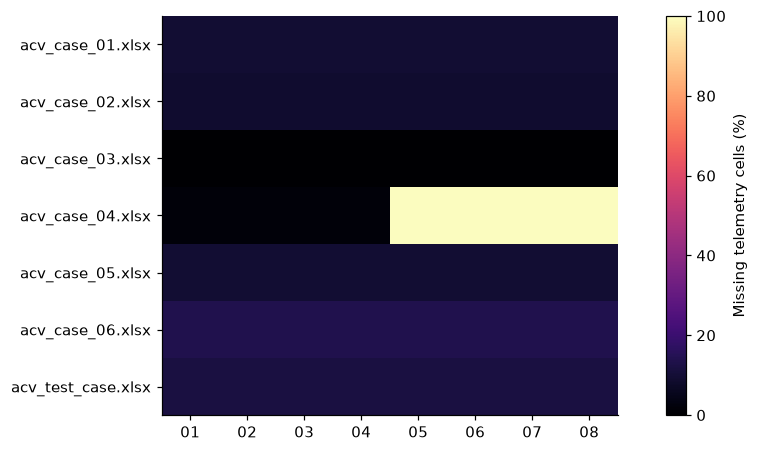

,filename,car,missing_pct,all_missing_columns
28,acv_case_04.xlsx,05,100.0,59
29,acv_case_04.xlsx,06,100.0,62
30,acv_case_04.xlsx,07,100.0,60
31,acv_case_04.xlsx,08,100.0,59


In [6]:
missing_rows=[]
for name,frame in raw.items():
    for car in cars[name]:
        cols=[col for (c,p),col in car_maps[name].items() if c==car]
        missing_rows.append({'filename':name,'car':car,'missing_pct':100*frame[cols].isna().mean().mean(),
                             'all_missing_columns':frame[cols].isna().all().sum()})
missing=pd.DataFrame(missing_rows)
matrix=missing.pivot(index='filename',columns='car',values='missing_pct')
fig,ax=plt.subplots(figsize=(10,4)); im=ax.imshow(matrix,vmin=0,vmax=100,cmap='magma')
ax.set(xticks=range(len(matrix.columns)),xticklabels=matrix.columns,yticks=range(len(matrix)),yticklabels=matrix.index)
fig.colorbar(im,ax=ax,label='Missing telemetry cells (%)'); plt.show()
display(missing.query('all_missing_columns > 0'))

<hr>
<div style="background-color: #ccccff; padding: 15px; border-radius: 10px;">
<h2 id="section-4" style="color: black;"><b>Section 4: Common-Parameter View and Operating Context</b></h2>
</div>

This section constructs a transparent long-form view while preserving raw data. Mappings between the simple and rich schemas are provisional semantic correspondences, not confirmed sensor equivalence.

<blockquote><h3 id="4-1"><b>4.1 Explicit Parameter Mapping</b></h3></blockquote>

Indoor/cabin, outdoor/fresh-air, and cooling-target columns are mapped explicitly. Alternative measurements may differ physically. Information-valid flags remain unknown where the richer schema lacks that field; no values are forward-filled.

In [7]:
ALIASES={
 'indoor':['Indoor Average Temperature','Passenger Cabin Temperature Detected Value'],
 'outdoor':['Outdoor Average Temperature','Outside Temperature Sensor Reading','Fresh Air Temperature Detected Value'],
 'target':['ACV Control Temperature (Cooling)','Target Temperature Value'],
 'mode':['ACV Running Mode'], 'valid':['ACV Information Valid'],
 'load':['Load Halved','Load Shedding']}
parts=[]; mappings=[]
for name,frame in raw.items():
    for car in cars[name]:
        block=pd.DataFrame({'time':times[name],'filename':name,'dataset':splits[name],'car':car})
        for field,aliases in ALIASES.items():
            found=[p for p in aliases if (car,p) in car_maps[name]]
            assert len(found)<=1, f'Ambiguous mapping: {name}, {car}, {field}'
            param=found[0] if found else None
            block[field]=frame[car_maps[name][(car,param)]] if param else np.nan
            mappings.append({'filename':name,'car':car,'field':field,'source_parameter':param})
        block['validity_field_available']=any((car,p) in car_maps[name] for p in ALIASES['valid'])
        block['label']='Unlabelled' if name not in label_map else ('Affected car' if car==label_map[name] else 'Other car')
        parts.append(block)
long=pd.concat(parts,ignore_index=True)
mapping_table=pd.DataFrame(mappings)
display(mapping_table.drop(columns='car').drop_duplicates())
conversion=[]
for col in ['indoor','outdoor','target']:
    numeric=pd.to_numeric(long[col],errors='coerce')
    conversion.append({'field':col,'nonnumeric_nonmissing':int((long[col].notna()&numeric.isna()).sum())})
    long[col]=numeric
display(pd.DataFrame(conversion))

,filename,field,source_parameter
0,acv_case_01.xlsx,indoor,Indoor Average Temperature
1,acv_case_01.xlsx,outdoor,Outdoor Average Temperature
2,acv_case_01.xlsx,target,ACV Control Temperature (Cooling)
3,acv_case_01.xlsx,mode,ACV Running Mode
4,acv_case_01.xlsx,valid,ACV Information Valid
5,acv_case_01.xlsx,load,Load Halved
48,acv_case_02.xlsx,indoor,Indoor Average Temperature
49,acv_case_02.xlsx,outdoor,Outdoor Average Temperature
50,acv_case_02.xlsx,target,ACV Control Temperature (Cooling)
51,acv_case_02.xlsx,mode,ACV Running Mode


,field,nonnumeric_nonmissing
0,indoor,0
1,outdoor,54678
2,target,0


<blockquote><h3 id="4-2"><b>4.2 Value Domains and Temperature Screens</b></h3></blockquote>

Mode, validity, and load domains are reported as observed strings. Zero and negative temperatures are flagged for inspection without assuming a physical impossibility or a confirmed sentinel convention.

In [8]:
for col in ['mode','valid','load']:
    display(long.groupby(['filename',col],dropna=False).size().rename('car_readings').reset_index())
display(long.groupby('filename')[['indoor','outdoor','target']].agg(['count','min','median','max']))
screen=long.groupby('filename')[['indoor','outdoor','target']].agg(lambda s:int(s.le(0).sum()))
display(screen.rename_axis('case: nonpositive readings by field'))

,filename,mode,car_readings
0,acv_case_01.xlsx,Automatic Cooling,46760
1,acv_case_01.xlsx,Emergency Ventilation,96
2,acv_case_01.xlsx,Full Cooling,34
3,acv_case_01.xlsx,Invalid,56
4,acv_case_01.xlsx,Stop,3630
5,acv_case_01.xlsx,NaN,5416
6,acv_case_02.xlsx,Automatic Cooling,66305
7,acv_case_02.xlsx,Emergency Ventilation,104
8,acv_case_02.xlsx,Invalid,49
9,acv_case_02.xlsx,Stop,598


,filename,valid,car_readings
0,acv_case_01.xlsx,Invalid,25
1,acv_case_01.xlsx,Valid,50551
2,acv_case_01.xlsx,NaN,5416
3,acv_case_02.xlsx,Invalid,44
4,acv_case_02.xlsx,Valid,67012
5,acv_case_02.xlsx,NaN,6440
6,acv_case_03.xlsx,Invalid,1
7,acv_case_03.xlsx,Valid,66479
8,acv_case_04.xlsx,NaN,178096
9,acv_case_05.xlsx,Valid,50384


,filename,load,car_readings
0,acv_case_01.xlsx,Normal,50576
1,acv_case_01.xlsx,NaN,5416
2,acv_case_02.xlsx,Normal,67056
3,acv_case_02.xlsx,NaN,6440
4,acv_case_03.xlsx,Normal,66480
5,acv_case_04.xlsx,No Load Shedding,87389
6,acv_case_04.xlsx,NaN,90707
7,acv_case_05.xlsx,Normal,50384
8,acv_case_05.xlsx,NaN,5392
9,acv_case_06.xlsx,Normal,22520


indoor                    outdoor                     \
                    count   min median   max   count   min median   max   
filename                                                                  
acv_case_01.xlsx    50576   0.0   24.0  32.5   50576   0.0   28.5  35.5   
acv_case_02.xlsx    67056   0.0   24.0  29.0   67056   0.0   32.5  39.0   
acv_case_03.xlsx    66480   0.0   24.5  30.5   66480   0.0   31.5  38.5   
acv_case_04.xlsx    87389  20.0   26.0  29.0   87389  24.0   33.0  44.0   
acv_case_05.xlsx    50384  17.0   23.0  26.5   12596  15.2   23.2  35.2   
acv_case_06.xlsx    22520  19.0   24.0  34.0    5630  30.2   36.2  46.2   
acv_test_case.xlsx  64112   0.0   24.0  29.5   64112   0.0   29.5  37.5   

                   target                     
                    count   min median   max  
filename                                      
acv_case_01.xlsx    50576   0.0   24.0  26.0  
acv_case_02.xlsx    67056   0.0   24.0  26.0  
acv_case_03.xlsx    66480   0.0   24.0  27.0  
acv_case_04.xlsx    87389  22.0   26.0  28.0  
acv_case_05.xlsx    50384  20.0   24.0  26.0  
acv_case_06.xlsx    22520  20.0   23.5  25.0  
acv_test_case.xlsx  64112   0.0   24.0  26.0

,indoor,outdoor,target
case: nonpositive readings by field,,,
acv_case_01.xlsx,25,25,25
acv_case_02.xlsx,44,44,44
acv_case_03.xlsx,1,1,1
acv_case_04.xlsx,0,0,0
acv_case_05.xlsx,0,0,0
acv_case_06.xlsx,0,0,0
acv_test_case.xlsx,25,25,25


<blockquote><h3 id="4-3"><b>4.3 Cooling and Validity Coverage</b></h3></blockquote>

Primary comparisons use observed cooling modes and finite indoor readings. A supplied information-valid field must explicitly read `Valid`; missing or non-valid states are excluded. Cases without that field retain unknown validity and remain separately identifiable. Comparisons are sample-weighted, not elapsed-time occupancy estimates.

In [9]:
COOLING_MODES=['Automatic Cooling','Full Cooling','Half Cooling']
long['cooling']=long['mode'].isin(COOLING_MODES)
long['validity_unknown']=long['valid'].isna()
long['explicit_valid']=long['valid'].eq('Valid')
long['eligible']=long.cooling & (long.explicit_valid|~long.validity_field_available) & np.isfinite(long.indoor)
coverage=long.groupby(['filename','car']).agg(readings=('time','size'),indoor_observed=('indoor','count'),
    eligible_rows=('eligible','sum'),unknown_validity=('validity_unknown','mean'),cooling_fraction=('cooling','mean'))
coverage['eligible_fraction']=coverage.eligible_rows/coverage.readings
display(coverage.round(3))

readings  indoor_observed  eligible_rows  \
filename           car                                             
acv_case_01.xlsx   01       6999             6322           5802   
                   02       6999             6322           5856   
                   03       6999             6322           5856   
                   04       6999             6322           5856   
                   05       6999             6322           5856   
                   06       6999             6322           5856   
                   07       6999             6322           5856   
                   08       6999             6322           5856   
acv_case_02.xlsx   01       9187             8382           8291   
                   02       9187             8382           8272   
                   03       9187             8382           8290   
                   04       9187             8382           8290   
                   05       9187             8382           8291   
                   06       9187             8382           8290   
                   07       9187             8382           8290   
                   08       9187             8382           8291   
acv_case_03.xlsx   01       8310             8310           8265   
                   02       8310             8310           8217   
                   03       8310             8310           8216   
                   04       8310             8310           8266   
                   05       8310             8310           8266   
                   06       8310             8310           8218   
                   07       8310             8310           8218   
                   08       8310             8310           7934   
acv_case_04.xlsx   01      22262            21849          20525   
                   02      22262            21849          21172   
                   03      22262            21849          21106   
                   04      22262            21842          21196   
                   05      22262                0              0   
                   06      22262                0              0   
                   07      22262                0              0   
                   08      22262                0              0   
acv_case_05.xlsx   01       6972             6298           6212   
                   02       6972             6298           6213   
                   03       6972             6298           6213   
                   04       6972             6298           6205   
                   05       6972             6298           6212   
                   06       6972             6298           6213   
                   07       6972             6298           6213   
                   08       6972             6298           6211   
acv_case_06.xlsx   01       3263             2815           2645   
                   02       3263             2815           2636   
                   03       3263             2815           2637   
                   04       3263             2815           2639   
                   05       3263             2815           2636   
                   06       3263             2815           2638   
                   07       3263             2815           2637   
                   08       3263             2815           2639   
acv_test_case.xlsx 01       9082             8014           7872   
                   02       9082             8014           7871   
                   03       9082             8014           7872   
                   04       9082             8014           7854   
                   05       9082             8014           7876   
                   06       9082             8014           7875   
                   07       9082             8014           7876   
                   08       9082             8014           7876   

                        unknown_validity  cooling_fraction  eligible_fraction  

<hr>
<div style="background-color: #ccccff; padding: 15px; border-radius: 10px;">
<h2 id="section-5" style="color: black;"><b>Section 5: Temperature Behaviour Within Cases</b></h2>
</div>

This section compares each car with its contemporaneous peers and its target. Peer comparisons reduce common ambient effects but cannot remove differences in passenger load, location, or sensor calibration.

<blockquote><h3 id="5-1"><b>5.1 Contemporaneous Peer Differences</b></h3></blockquote>

Each eligible indoor reading is compared with the median of the other eligible cars at the same recorded timestamp. At least three peers are required. The affected-car label is not used to select peers, and no interpolation bridges gaps.

In [10]:
long['peer_delta']=np.nan; long['peer_count']=0
for name in raw:
    subset=long.loc[long.filename.eq(name)]
    values=subset.assign(value=subset.indoor.where(subset.eligible)).pivot(index='time',columns='car',values='value')
    for car in cars[name]:
        peers=values.drop(columns=car)
        count=peers.notna().sum(axis=1)
        delta=(values[car]-peers.median(axis=1)).where(count>=3)
        idx=long.index[long.filename.eq(name)&long.car.eq(car)]
        long.loc[idx,'peer_delta']=long.loc[idx,'time'].map(delta).to_numpy()
        long.loc[idx,'peer_count']=long.loc[idx,'time'].map(count).to_numpy()
long['target_error']=(long.indoor-long.target).where(long.eligible & np.isfinite(long.target))
long['indoor_outdoor_delta']=(long.indoor-long.outdoor).where(long.eligible & np.isfinite(long.outdoor))
display(long.groupby('filename').agg(peer_comparisons=('peer_delta','count'),eligible_rows=('eligible','sum')))

,peer_comparisons,eligible_rows
filename,,
acv_case_01.xlsx,46794,46794
acv_case_02.xlsx,66305,66305
acv_case_03.xlsx,65456,65600
acv_case_04.xlsx,81588,83999
acv_case_05.xlsx,49691,49692
acv_case_06.xlsx,21094,21107
acv_test_case.xlsx,62971,62972


<blockquote><h3 id="5-2"><b>5.2 Train Case Profiles</b></h3></blockquote>

Resampled 15-minute medians provide readable profile plots. Empty bins remain gaps, and the resampling is for display only. Affected-car lines reflect case-level labels rather than known fault onset.

C:\Users\user\AppData\Local\Temp\ipykernel_37008\350876553.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[row,0].legend(title='Affected car')


C:\Users\user\AppData\Local\Temp\ipykernel_37008\350876553.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[row,0].legend(title='Affected car')
C:\Users\user\AppData\Local\Temp\ipykernel_37008\350876553.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[row,0].legend(title='Affected car')


C:\Users\user\AppData\Local\Temp\ipykernel_37008\350876553.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[row,0].legend(title='Affected car')
C:\Users\user\AppData\Local\Temp\ipykernel_37008\350876553.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[row,0].legend(title='Affected car')
C:\Users\user\AppData\Local\Temp\ipykernel_37008\350876553.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[row,0].legend(title='Affected car')


C:\Users\user\AppData\Local\Temp\ipykernel_37008\350876553.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[row,0].legend(title='Affected car')
C:\Users\user\AppData\Local\Temp\ipykernel_37008\350876553.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[row,0].legend(title='Affected car')
C:\Users\user\AppData\Local\Temp\ipykernel_37008\350876553.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[row,0].legend(title='Affected car')
C:\Users\user\AppData\Local\Temp\ipykernel_37008\350876553.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start 

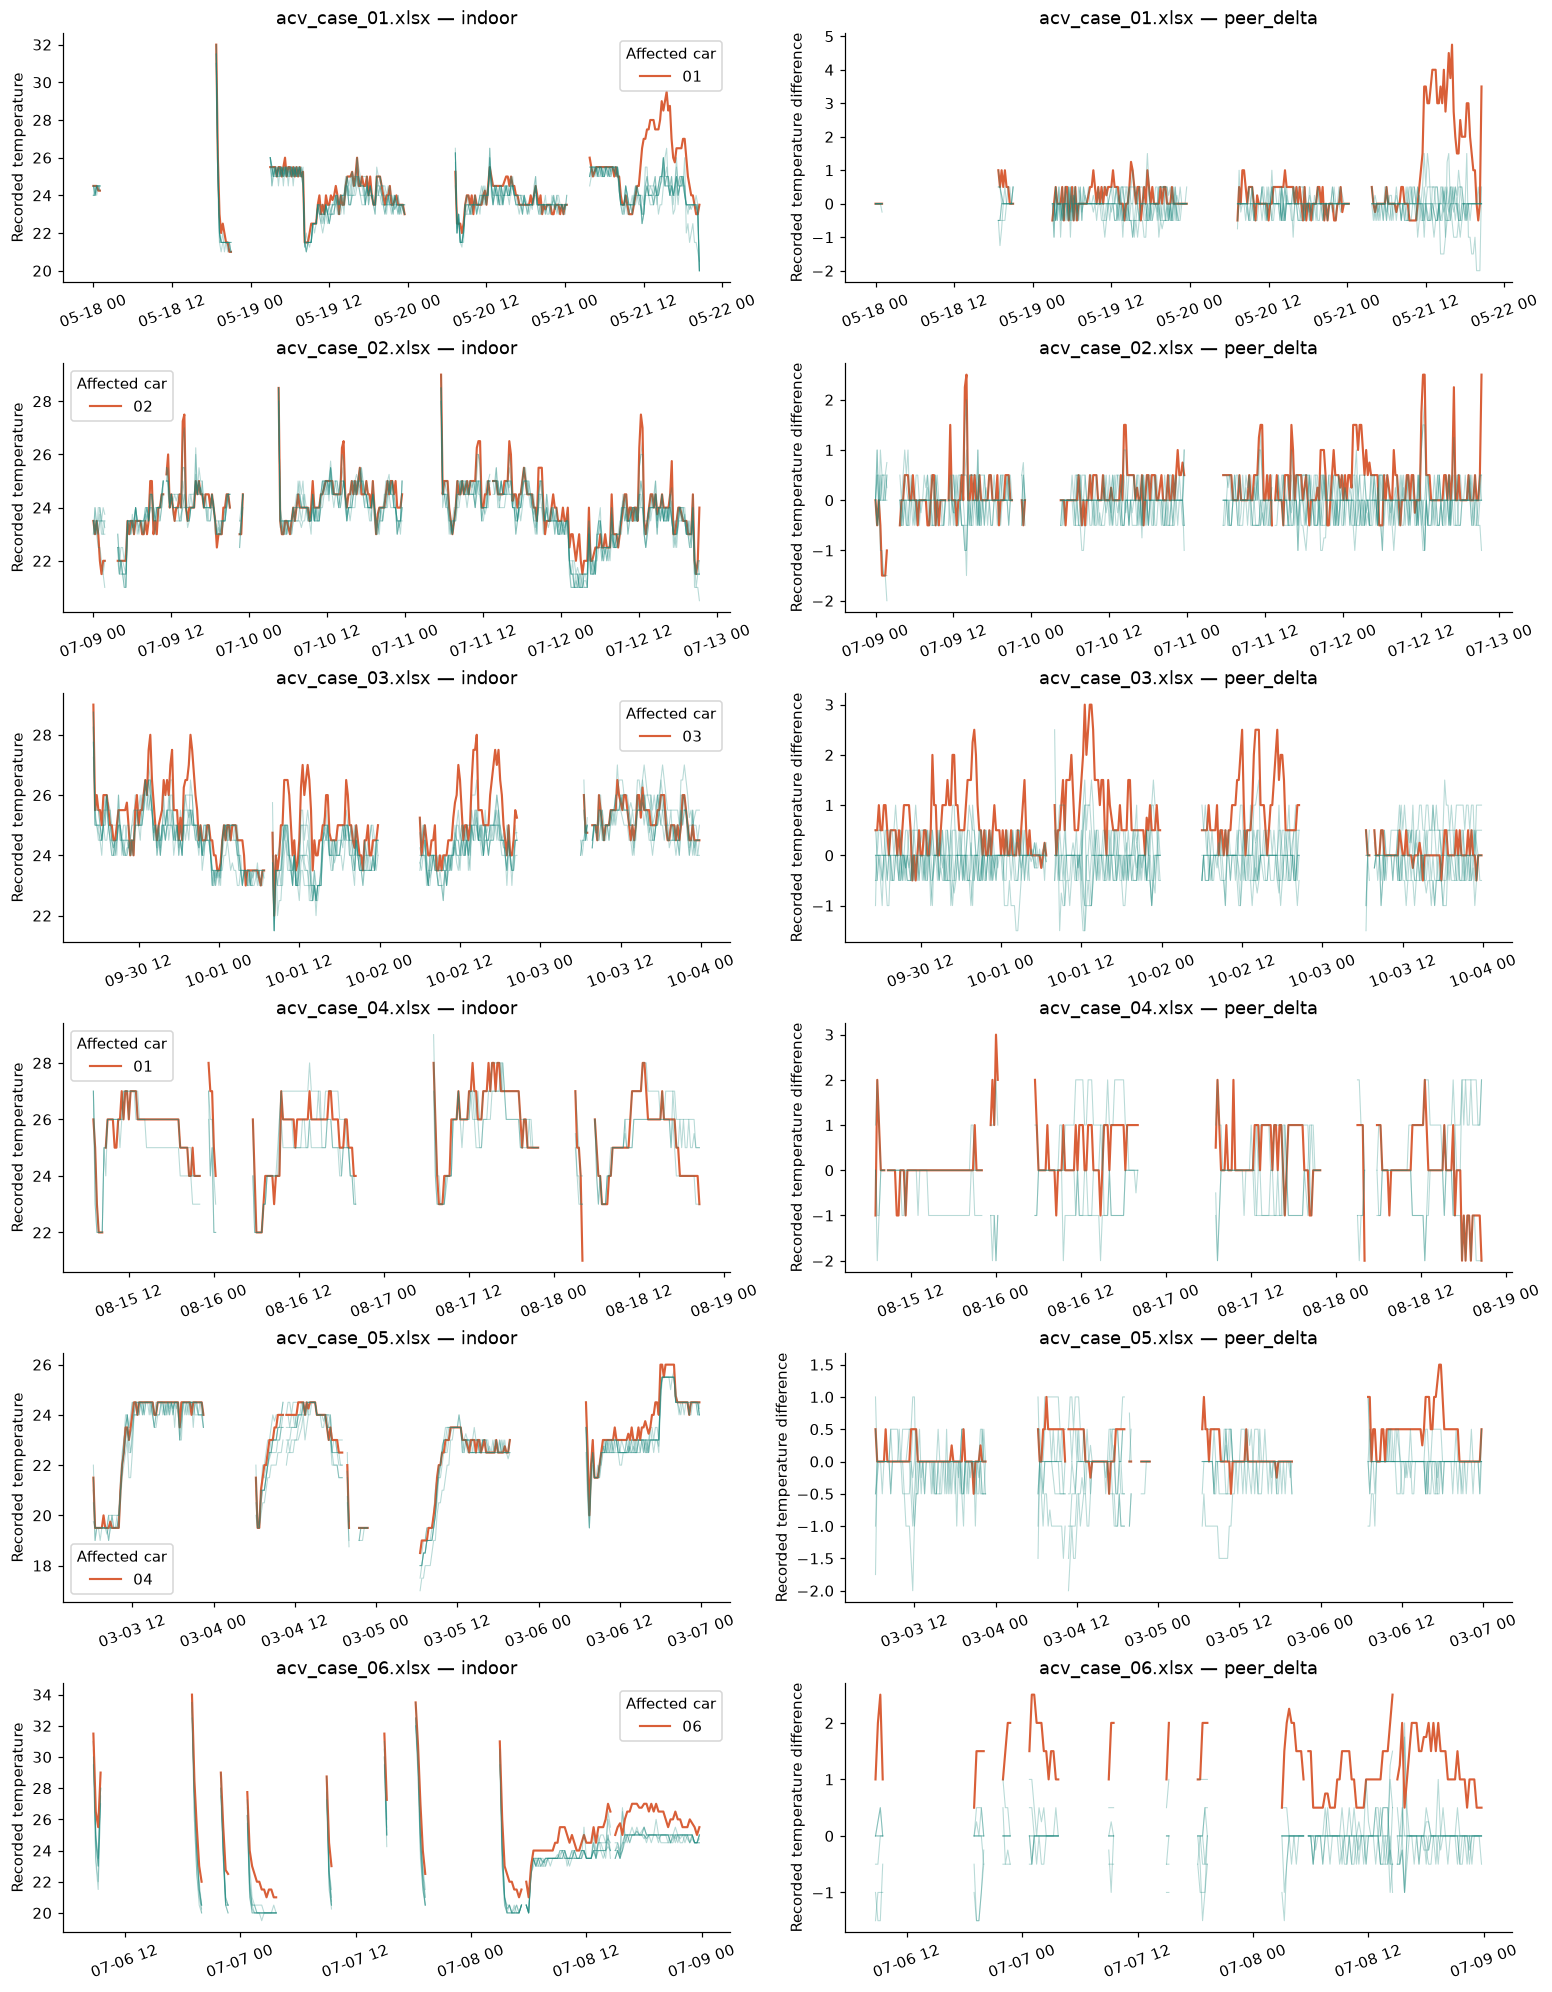

In [11]:
train_names=[name for name in raw if splits[name]=='Train']
fig,axes=plt.subplots(len(train_names),2,figsize=(14,3*len(train_names)),squeeze=False)
for row,name in enumerate(train_names):
    for car in cars[name]:
        g=long.loc[long.filename.eq(name)&long.car.eq(car)].set_index('time')
        affected=car==label_map[name]
        color=COLORS['Affected car'] if affected else COLORS['Other car']
        for ax,field in zip(axes[row],['indoor','peer_delta']):
            series=g[field].where(g.eligible).resample('15min').median()
            ax.plot(series.index,series,color=color,alpha=1 if affected else .3,lw=1.4 if affected else .7,label=car if affected else None)
            ax.set(title=name+' — '+field,ylabel='Recorded temperature difference' if field=='peer_delta' else 'Recorded temperature')
            ax.tick_params(axis='x',rotation=20)
        axes[row,0].legend(title='Affected car')
plt.show()

<blockquote><h3 id="5-3"><b>5.3 Operating-Mode Confounding</b></h3></blockquote>

Median indoor temperature and target error are compared by recorded mode and car label. Counts quantify unequal exposure; pooled rows are not independent cases and cannot support a fault-detection accuracy claim.

In [12]:
context=long.groupby(['filename','label','mode'],dropna=False).agg(rows=('time','size'),
    indoor_median=('indoor','median'),target_error_median=('target_error','median'))
display(context)

rows  indoor_median  \
filename           label        mode                                          
acv_case_01.xlsx   Affected car Automatic Cooling       5794          24.00   
                                Emergency Ventilation     12          23.75   
                                Full Cooling               8          27.50   
                                Invalid                   56          28.00   
                                Stop                     452          27.50   
                                NaN                      677            NaN   
                   Other car    Automatic Cooling      40966          24.00   
                                Emergency Ventilation     84          24.00   
                                Full Cooling              26          24.00   
                                Stop                    3178          28.00   
                                NaN                     4739            NaN   
acv_case_02.xlsx   Affected car Automatic Cooling       8272          24.00   
                                Emergency Ventilation     13          25.00   
                                Invalid                   45           0.00   
                                Stop                      52          28.50   
                                NaN                      805            NaN   
                   Other car    Automatic Cooling      58033          24.00   
                                Emergency Ventilation     91          25.00   
                                Invalid                    4          23.00   
                                Stop                     546          27.50   
                                NaN                     5635            NaN   
acv_case_03.xlsx   Affected car Automatic Cooling       8216          25.00   
                                Emergency Ventilation      1          24.00   
                                Invalid                    1           0.00   
                                Stop                      44          29.50   
                                Ventilation               48          28.50   
                   Other car    Automatic Cooling      57371          24.50   
                                Emergency Ventilation      2          23.50   
                                Half Cooling              13          23.00   
                                Stop                     308          29.50   
                                Ventilation              476          28.00   
acv_case_04.xlsx   Affected car Emergency Ventilation     38          26.00   
                                Full Cooling            7453          26.00   
                                Half Cooling           13072          26.00   
                                Self-Check                 1          28.00   
                                Stopped                  354          26.00   
                                Ventilation              931          25.00   
                                NaN                      413            NaN   
                   Other car    Emergency Ventilation    114          25.00   
                                Full Cooling           48756          26.00   
                                Half Cooling           14718          25.00   
                                Self-Check                 3          28.00   
                                Stopped                 1062          26.00   
                                Ventilation              887          25.00   
                                NaN                    90294            NaN   
acv_case_05.xlsx   Affected car Automatic Cooling       6204          23.50   
                                Emergency Ventilation     80          21.50   
                                Half Cooling               1          21.00   
                                Stop                       4          21.00   
                           

<hr>
<div style="background-color: #ccccff; padding: 15px; border-radius: 10px;">
<h2 id="section-6" style="color: black;"><b>Section 6: Case-and-Car Feature Exploration</b></h2>
</div>

This section creates interpretable summaries for later ranking experiments. Each case contributes eight related car observations, while only six labelled case files are available and their independence is unverified.

<blockquote><h3 id="6-1"><b>6.1 Candidate Features and Coverage</b></h3></blockquote>

Features summarise cooling temperature, target deviation, peer contrast, persistence across hourly bins, and contiguous-step temperature changes. A fixed one-unit contrast is descriptive, not a validated alarm threshold. Large timestamp gaps are excluded from step changes.

In [13]:
feature_rows=[]
for (name,car),g in long.groupby(['filename','car'],sort=True):
    g=g.sort_values('time').copy(); eligible=g.loc[g.eligible]
    step=g.time.diff().dt.total_seconds()
    cadence=quality.loc[name,'modal_step_s']
    contiguous=step.gt(0)&step.le(1.5*cadence)&g.eligible&g.eligible.shift(fill_value=False)
    slope=(g.indoor.diff()/step*60).where(contiguous)
    peer=g.peer_delta.dropna()
    hourly=g.set_index('time').peer_delta.resample('1h').agg(['median','count'])
    # Require at least ten observed peer comparisons per hourly display bin.
    hourly=hourly.loc[hourly['count']>=10,'median']
    feature_rows.append({'filename':name,'car':car,'dataset':splits[name],'label':g.label.iloc[0],
        'eligible_n':len(eligible),'peer_n':len(peer),'hour_bins':len(hourly),
        'indoor_median':eligible.indoor.median(),'target_error_median':g.target_error.median(),
        'target_error_p90':g.target_error.quantile(.9),'peer_delta_median':peer.median(),
        'peer_delta_p90':peer.quantile(.9),'peer_above_one_fraction':peer.gt(1).mean() if len(peer) else np.nan,
        'hourly_peer_above_one_fraction':hourly.gt(1).mean() if len(hourly) else np.nan,
        'indoor_outdoor_median':g.indoor_outdoor_delta.median(),
        'abs_step_per_minute_p95':slope.abs().quantile(.95)})
features=pd.DataFrame(feature_rows)
FEATURES=['indoor_median','target_error_median','target_error_p90','peer_delta_median','peer_delta_p90',
          'peer_above_one_fraction','hourly_peer_above_one_fraction','indoor_outdoor_median','abs_step_per_minute_p95']
display(features)
display(features.groupby('dataset')[FEATURES].agg(lambda s:s.isna().sum()).rename_axis('missing feature values'))

,filename,car,dataset,label,eligible_n,peer_n,hour_bins,indoor_median,target_error_median,target_error_p90,peer_delta_median,peer_delta_p90,peer_above_one_fraction,hourly_peer_above_one_fraction,indoor_outdoor_median,abs_step_per_minute_p95
0,acv_case_01.xlsx,01,Train,Affected car,5802,5802,61,24.5,0.0,4.5,0.0,2.0,0.126680,0.114754,-5.0,1.0
1,acv_case_01.xlsx,02,Train,Other car,5856,5856,61,24.0,-0.5,1.5,0.0,0.5,0.017930,0.000000,-4.5,1.0
2,acv_case_01.xlsx,03,Train,Other car,5856,5856,61,24.0,-0.5,1.0,0.0,0.5,0.003245,0.000000,-5.5,1.0
3,acv_case_01.xlsx,04,Train,Other car,5856,5856,61,24.0,-0.5,1.0,0.0,0.5,0.000854,0.000000,-5.0,1.0
4,acv_case_01.xlsx,05,Train,Other car,5856,5856,61,24.0,-0.5,0.5,0.0,0.5,0.001195,0.000000,-5.5,1.0
5,acv_case_01.xlsx,06,Train,Other car,5856,5856,61,24.0,-0.5,0.5,0.0,0.5,0.001025,0.000000,-5.5,1.0
6,acv_case_01.xlsx,07,Train,Other car,5856,5856,61,24.0,-0.5,0.5,0.0,0.5,0.001025,0.000000,-5.0,1.0
7,acv_case_01.xlsx,08,Train,Other car,5856,5856,61,24.0,-0.5,0.5,0.0,0.5,0.005123,0.000000,-4.5,1.0
8,acv_case_02.xlsx,01,Train,Other car,8291,8291,84,24.0,0.0,1.0,0.0,0.5,0.010855,0.011905,-8.5,1.0
9,acv_case_02.xlsx,02,Train,Affected car,8272,8272,84,24.0,0.5,1.5,0.0,1.0,0.056939,0.035714,-8.5,1.0


,indoor_median,target_error_median,target_error_p90,peer_delta_median,peer_delta_p90,peer_above_one_fraction,hourly_peer_above_one_fraction,indoor_outdoor_median,abs_step_per_minute_p95
missing feature values,,,,,,,,,
Test,0,0,0,0,0,0,0,0,0
Train,4,4,4,4,4,4,4,16,4


<blockquote><h3 id="6-2"><b>6.2 Within-Case Labelled Contrasts</b></h3></blockquote>

The affected-car value is compared with the median of the seven other cars within each Train case. This gives one contrast per labelled case rather than a pooled row-level effect. Signs may vary by operating conditions and feature meaning.

,indoor_median,target_error_median,target_error_p90,peer_delta_median,peer_delta_p90,peer_above_one_fraction,hourly_peer_above_one_fraction,indoor_outdoor_median,abs_step_per_minute_p95
acv_case_01.xlsx,0.5,0.5,4.0,0.0,1.5,0.125,0.115,0.0,0.0
acv_case_02.xlsx,0.0,0.5,0.5,0.0,0.5,0.055,0.036,0.5,0.0
acv_case_03.xlsx,0.5,0.0,1.0,0.5,1.0,0.173,0.133,0.5,0.0
acv_case_04.xlsx,0.0,0.0,0.0,0.0,0.0,-0.005,-0.015,0.0,0.0
acv_case_05.xlsx,0.5,0.0,0.0,0.0,0.0,0.011,0.015,NaN,0.0
acv_case_06.xlsx,1.0,1.5,1.5,1.5,1.5,0.559,0.571,NaN,0.0


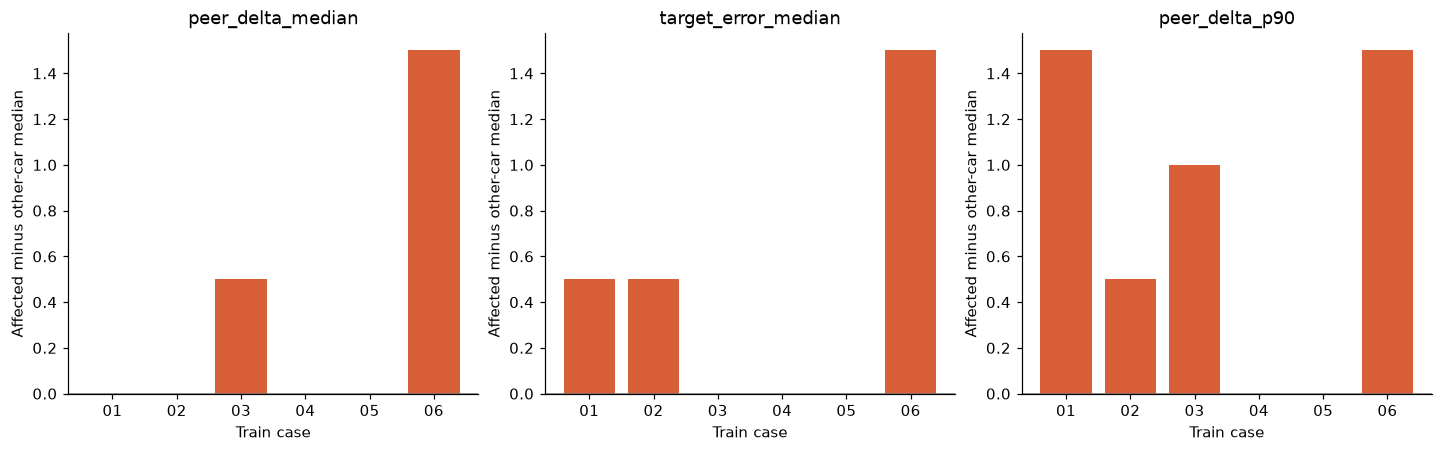

In [14]:
contrasts=[]
for name in train_names:
    f=features.query('filename == @name').set_index('car')
    affected=label_map[name]
    contrasts.append(pd.Series(f.loc[affected,FEATURES].astype(float)-f.drop(index=affected)[FEATURES].median(),name=name))
contrasts=pd.DataFrame(contrasts)
display(contrasts.round(3))
fig,axes=plt.subplots(1,3,figsize=(13,4))
for ax,col in zip(axes,['peer_delta_median','target_error_median','peer_delta_p90']):
    ax.bar(np.arange(len(contrasts)),contrasts[col],color=COLORS['Affected car'])
    ax.axhline(0,color='grey',lw=1)
    ax.set(title=col,xticks=range(len(contrasts)),xticklabels=[n.replace('acv_case_','').replace('.xlsx','') for n in contrasts.index],ylabel='Affected minus other-car median',xlabel='Train case')
plt.show()

<blockquote><h3 id="6-3"><b>6.3 Sensitivity to Suspicious Temperature Values</b></h3></blockquote>

An explicit alternative screen retains indoor and target readings between 5 and 60 recorded units. This broad range is an exploratory sensitivity choice, not a documented validity rule. Changes in peer contrasts indicate whether conclusions depend on unusual measurements.

In [15]:
sensitivity=[]
for name in raw:
    g=long.loc[long.filename.eq(name)].copy()
    g['screened']=g.indoor.where(g.eligible & g.indoor.between(5,60)&g.target.between(5,60))
    values=g.pivot(index='time',columns='car',values='screened')
    for car in cars[name]:
        peers=values.drop(columns=car)
        delta=(values[car]-peers.median(axis=1)).where(peers.notna().sum(axis=1)>=3)
        base=g.loc[g.car.eq(car),'peer_delta']
        sensitivity.append({'filename':name,'car':car,'original_n':base.count(),'screened_n':delta.count(),
            'original_median':base.median(),'screened_median':delta.median()})
sensitivity=pd.DataFrame(sensitivity)
sensitivity['median_change']=sensitivity.screened_median-sensitivity.original_median
display(sensitivity)

,filename,car,original_n,screened_n,original_median,screened_median,median_change
0,acv_case_01.xlsx,01,5802,5802,0.0,0.0,0.0
1,acv_case_01.xlsx,02,5856,5856,0.0,0.0,0.0
2,acv_case_01.xlsx,03,5856,5856,0.0,0.0,0.0
3,acv_case_01.xlsx,04,5856,5856,0.0,0.0,0.0
4,acv_case_01.xlsx,05,5856,5856,0.0,0.0,0.0
5,acv_case_01.xlsx,06,5856,5856,0.0,0.0,0.0
6,acv_case_01.xlsx,07,5856,5856,0.0,0.0,0.0
7,acv_case_01.xlsx,08,5856,5856,0.0,0.0,0.0
8,acv_case_02.xlsx,01,8291,8291,0.0,0.0,0.0
9,acv_case_02.xlsx,02,8272,8272,0.0,0.0,0.0


<hr>
<div style="background-color: #ccccff; padding: 15px; border-radius: 10px;">
<h2 id="section-7" style="color: black;"><b>Section 7: Rich-Schema Telemetry and Portability</b></h2>
</div>

This section examines parameters available only in the richer case. Additional sensors can support case review but cannot automatically become shared features for simpler Train or Test schemas.

<blockquote><h3 id="7-1"><b>7.1 Additional Temperature and Pressure Channels</b></h3></blockquote>

Numeric ranges and missingness are reported for rich-schema temperature and pressure channels. Pressure scaling, engineering limits, and sentinel conventions are not supplied, so extremes are inspection candidates rather than diagnosed sensor failures.

In [16]:
rich_names=[n for n in raw if len(car_maps[n])>100]
rich_ranges=[]
for name in rich_names:
    for (car,param),col in car_maps[name].items():
        if 'Temperature' in param or 'Pressure Value' in param:
            s=pd.to_numeric(raw[name][col],errors='coerce')
            rich_ranges.append({'filename':name,'car':car,'parameter':param,'observed':s.count(),
                                'min':s.min(),'median':s.median(),'max':s.max(),'nonpositive':s.le(0).sum()})
rich_ranges=pd.DataFrame(rich_ranges)
display(rich_ranges)

,filename,car,parameter,observed,min,median,max,nonpositive
0,acv_case_04.xlsx,08,Target Temperature -2K,0,NaN,NaN,NaN,0
1,acv_case_04.xlsx,01,Target Temperature -2K,21849,0.0,0.0,0.0,21849
2,acv_case_04.xlsx,01,Target Temperature -1K,21849,0.0,0.0,0.0,21849
3,acv_case_04.xlsx,08,Target Temperature -1K,0,NaN,NaN,NaN,0
4,acv_case_04.xlsx,01,Target Temperature 0,21849,0.0,0.0,1.0,21848
...,...,...,...,...,...,...,...,...
99,acv_case_04.xlsx,05,Refrigeration System 1 Low Pressure Value,0,NaN,NaN,NaN,0
100,acv_case_04.xlsx,04,Refrigeration System 2 High Pressure Value,21842,560.0,2000.0,2560.0,0
101,acv_case_04.xlsx,05,Refrigeration System 2 High Pressure Value,0,NaN,NaN,NaN,0
102,acv_case_04.xlsx,05,Refrigeration System 2 Low Pressure Value,0,NaN,NaN,NaN,0


<blockquote><h3 id="7-2"><b>7.2 Schema Availability for Future Features</b></h3></blockquote>

Parameter coverage is compared across cases. Fault-status columns require engineering review before future use because they may encode an existing diagnosis rather than an early precursor.

In [17]:
availability=parameter_presence.copy()
availability['cases_available']=parameter_presence.sum(axis=1)
display(availability.sort_values('cases_available',ascending=False))
print('Fault-named parameters:',[p for p in parameter_presence.index if 'Fault' in p])
print('Shared parameters across every case:',parameter_presence.index[parameter_presence.all(axis=1)].tolist())

filename,acv_case_01.xlsx,acv_case_02.xlsx,acv_case_03.xlsx,acv_case_04.xlsx,acv_case_05.xlsx,acv_case_06.xlsx,acv_test_case.xlsx,cases_available
parameter,,,,,,,,
ACV Running Mode,True,True,True,True,True,True,True,7
ACV Control Temperature (Heating),True,True,True,False,True,True,True,6
ACV Control Temperature (Cooling),True,True,True,False,True,True,True,6
Indoor Average Temperature,True,True,True,False,True,True,True,6
Load Halved,True,True,True,False,True,True,True,6
ACV Setting Mode,True,True,True,False,True,True,True,6
ACV Information Valid,True,True,True,False,True,True,True,6
Outdoor Average Temperature,True,True,True,False,False,False,True,4
Outside Temperature Sensor Reading,False,False,False,False,True,True,False,2


Fault-named parameters: ['Compressor 1 Fault', 'Compressor 2 Fault', 'Condenser Fan 1 Fault', 'Condenser Fan 2 Fault', 'Electric Heater 1 Fault', 'Electric Heater 2 Fault', 'Exhaust Fan Fault', 'Ventilation Fan 1 Fault', 'Ventilation Fan 2 Fault']
Shared parameters across every case: ['ACV Running Mode']


<hr>
<div style="background-color: #ccccff; padding: 15px; border-radius: 10px;">
<h2 id="section-8" style="color: black;"><b>Section 8: Unlabelled Test Coverage</b></h2>
</div>

This section assesses whether the Test schema and operating conditions are represented in Train without generating a car ranking or inferred Test labels.

<blockquote><h3 id="8-1"><b>8.1 Feature Ranges and Context</b></h3></blockquote>

Test feature ranges are compared with Train case-car ranges. Dependence among cars and the small number of cases limit interpretation of pooled distributions.

,train_min,train_median,train_max,test_min,test_median,test_max,test_cars_outside_train_range
indoor_median,22.5,24.000000,26.000000,24.0,24.000000,24.500000,0
target_error_median,-0.5,0.000000,1.500000,0.0,0.000000,0.000000,0
target_error_p90,0.0,1.000000,5.000000,0.5,1.000000,1.000000,0
peer_delta_median,-0.5,0.000000,1.500000,0.0,0.000000,0.000000,0
peer_delta_p90,0.0,0.500000,2.000000,0.5,0.500000,1.000000,0
peer_above_one_fraction,0.0,0.003329,0.566174,0.0,0.002033,0.027693,0
hourly_peer_above_one_fraction,0.0,0.000000,0.571429,0.0,0.000000,0.000000,0
indoor_outdoor_median,-15.7,-7.000000,0.800000,-6.0,-6.000000,-5.000000,0
abs_step_per_minute_p95,0.0,1.000000,1.000000,1.0,1.000000,1.000000,0


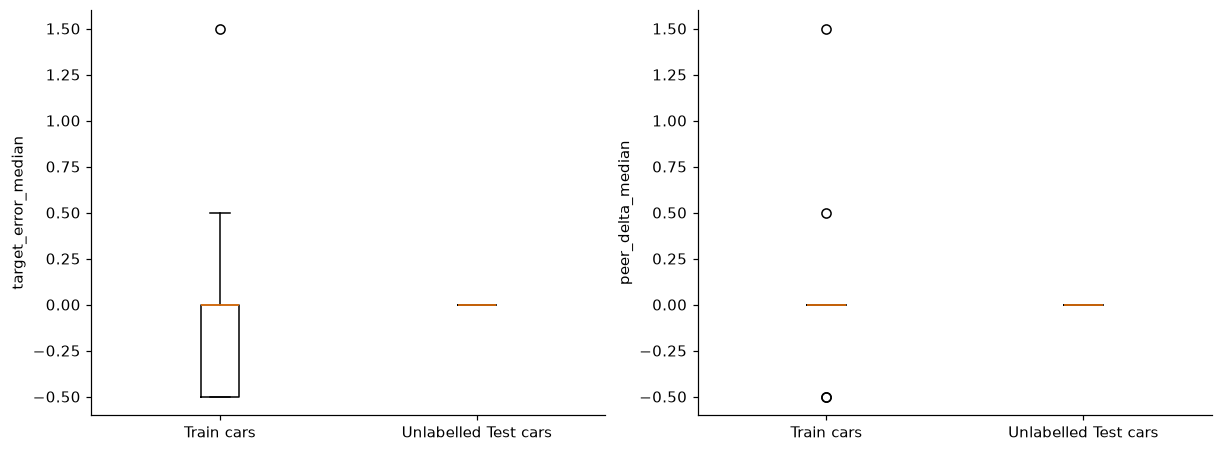

In [18]:
train_f=features.query("dataset == 'Train'")
test_f=features.query("dataset == 'Test'")
shift=pd.DataFrame({'train_min':train_f[FEATURES].min(),'train_median':train_f[FEATURES].median(),
 'train_max':train_f[FEATURES].max(),'test_min':test_f[FEATURES].min(),'test_median':test_f[FEATURES].median(),
 'test_max':test_f[FEATURES].max(),
 'test_cars_outside_train_range':((test_f[FEATURES]<train_f[FEATURES].min())|(test_f[FEATURES]>train_f[FEATURES].max())).sum()})
display(shift)
fig,axes=plt.subplots(1,2,figsize=(11,4))
for ax,col in zip(axes,['target_error_median','peer_delta_median']):
    ax.boxplot([train_f[col].dropna(),test_f[col].dropna()],tick_labels=['Train cars','Unlabelled Test cars'])
    ax.set(ylabel=col)
plt.show()

<hr>
<div style="background-color: #ccccff; padding: 15px; border-radius: 10px;">
<h2 id="section-9" style="color: black;"><b>Section 9: Validation Planning and Scoring</b></h2>
</div>

This section describes case-level validation and the official rank-decay metric. No classifier, ranker, or fitted preprocessing is trained in this notebook.

<blockquote><h3 id="9-1"><b>9.1 Leave-One-Case-Out Plan</b></h3></blockquote>

All cars, rows, and windows from a held-out case remain together. Six leave-one-case-out folds provide a provisional assessment plan, with additional grouping by train or session needed if shared origins create dependence.

In [19]:
folds=pd.DataFrame([{'fold':i+1,'held_out_case':name,'training_cases':len(train_names)-1,
                    'validation_cars':len(cars[name]),'affected_car':label_map[name]} for i,name in enumerate(train_names)])
display(folds)
display(labels.faulty_car.value_counts().rename('labelled_cases').rename_axis('car_identifier'))
planning=pd.DataFrame([
 ('Independent evidence','Six labelled cases, not thousands of independent positive rows; no fault-onset annotations are provided.'),
 ('Feature fitting','Any imputation, scaling, selection, threshold choice, and tuning must use training cases only.'),
 ('Identifiers','Filename, date, car ID, and train number are context/grouping metadata; memorising them is not fault localisation.'),
 ('Peer context','Contemporaneous peer comparisons are available at inference; retrospective hourly summaries require the relevant observations.'),
 ('Schema transfer','Verify proxy sensor equivalence and missing-field behaviour; richer fault and pressure telemetry is not universally available.'),
 ('Evaluation','Report held-out case ranks and official scores individually, plus mean score and top-1 recall; six cases imply substantial uncertainty.'),
 ('Test discipline','Keep Test unlabelled; do not choose features or thresholds to produce a preferred Test ranking.')
],columns=['topic','constraint'])
display(planning)

,fold,held_out_case,training_cases,validation_cars,affected_car
0,1,acv_case_01.xlsx,5,8,01
1,2,acv_case_02.xlsx,5,8,02
2,3,acv_case_03.xlsx,5,8,03
3,4,acv_case_04.xlsx,5,8,01
4,5,acv_case_05.xlsx,5,8,04
5,6,acv_case_06.xlsx,5,8,06


car_identifier
01    2
02    1
03    1
04    1
06    1
Name: labelled_cases, dtype: int64

,topic,constraint
0,Independent evidence,"Six labelled cases, not thousands of independe..."
1,Feature fitting,"Any imputation, scaling, selection, threshold ..."
2,Identifiers,"Filename, date, car ID, and train number are c..."
3,Peer context,Contemporaneous peer comparisons are available...
4,Schema transfer,Verify proxy sensor equivalence and missing-fi...
5,Evaluation,Report held-out case ranks and official scores...
6,Test discipline,Keep Test unlabelled; do not choose features o...


<blockquote><h3 id="9-2"><b>9.2 Official Rank-Decay Illustration</b></h3></blockquote>

For a correct-car rank `r` among `n` cars, the score is `(n - (r - 1)) / n`. The table illustrates the formula for eight cars; it is not evaluated model performance. A missing true car scores zero under the information kit.

In [20]:
ranks=np.arange(1,9)
display(pd.DataFrame({'true_car_rank':ranks,'official_score':(8-(ranks-1))/8}))
print('Expected score under a uniformly random complete ranking:',np.mean((8-(ranks-1))/8))

,true_car_rank,official_score
0,1,1.000
1,2,0.875
2,3,0.750
3,4,0.625
4,5,0.500
5,6,0.375
6,7,0.250
7,8,0.125


Expected score under a uniformly random complete ranking: 0.5625


<hr>
<div style="background-color: #ccccff; padding: 15px; border-radius: 10px;">
<h2 id="section-10" style="color: black;"><b>Section 10: Results Inventory and Conclusions</b></h2>
</div>

This section consolidates observed audit results and the limitations relevant to later model development.

<blockquote><h3 id="10-1"><b>10.1 Reproducible Audit Summary</b></h3></blockquote>

The following summary records case counts, schema and timing differences, peer coverage, and the number of positive affected-car contrasts. These are descriptive EDA results, not predictive scores.

In [21]:
summary={'train_cases':len(train_names),'test_cases':sum(s=='Test' for s in splits.values()),
 'case_car_rows':len(features),'workbook_rows':int(inventory.rows.sum()),
 'modal_steps_s':quality.modal_step_s.to_dict(),
 'missing_pct':quality.missing_pct.round(3).to_dict(),
 'rich_schema_cases':rich_names,
 'no_peer_feature_cars':int(features.peer_delta_median.isna().sum()),
 'positive_affected_peer_median_cases':int(contrasts.peer_delta_median.gt(0).sum()),
 'positive_affected_target_error_cases':int(contrasts.target_error_median.gt(0).sum()),
 'test_features_outside_train_range':int(shift.test_cars_outside_train_range.gt(0).sum())}
print(json.dumps(summary,indent=2))

{
  "train_cases": 6,
  "test_cases": 1,
  "case_car_rows": 56,
  "workbook_rows": 66075,
  "modal_steps_s": {
    "acv_case_01.xlsx": 30.0,
    "acv_case_02.xlsx": 30.0,
    "acv_case_03.xlsx": 30.0,
    "acv_case_04.xlsx": 10.0,
    "acv_case_05.xlsx": 30.0,
    "acv_case_06.xlsx": 30.0,
    "acv_test_case.xlsx": 30.0
  },
  "missing_pct": {
    "acv_case_01.xlsx": 9.24,
    "acv_case_02.xlsx": 8.37,
    "acv_case_03.xlsx": 0.0,
    "acv_case_04.xlsx": 50.615,
    "acv_case_05.xlsx": 9.234,
    "acv_case_06.xlsx": 13.115,
    "acv_test_case.xlsx": 11.233
  },
  "rich_schema_cases": [
    "acv_case_04.xlsx"
  ],
  "no_peer_feature_cars": 4,
  "positive_affected_peer_median_cases": 2,
  "positive_affected_target_error_cases": 3,
  "test_features_outside_train_range": 0
}


<blockquote><h3 id="10-2"><b>10.2 Verified Findings</b></h3></blockquote>

- The audit covers six Train cases and one Test case, containing 66,075 workbook rows and eight car identifiers per case. The resulting feature table contains 56 case-car rows; these are not independent labelled experiments.
- `acv_case_04.xlsx` has 483 columns and a modal sampling interval of 10 seconds. The other workbooks have 67 columns and modal intervals of 30 seconds. Observed gaps require elapsed-time handling rather than a universal row-count-to-duration conversion.
- The richer case has approximately 50.6% missing workbook cells. Cars `05`–`08` have no observed cabin-temperature values in that case, leaving 4 case-car peer-median features undefined. A later ranker must still include every required car while handling missing evidence explicitly.
- Two simpler cases use `Outside Temperature Sensor Reading` rather than `Outdoor Average Temperature`. The mapping is explicit, and equivalence to fresh-air telemetry in the richer case remains an engineering assumption.
- The affected car has a strictly positive median-peer contrast relative to the median of the other cars in 2 of six Train cases. Median target-error contrasts are positive in 3 cases. Whole-case medians alone therefore do not consistently distinguish the labelled car; upper-tail and persistence summaries merit later validation.
- 0 candidate features contain a Test car value outside the corresponding observed Train range. Range coverage alone does not establish transfer performance or identify the faulty Test car.
- With eight cars, the official score for a uniformly random complete ranking has expectation 0.5625. Future performance should be interpreted alongside per-case ranks and this metric context, rather than treating any positive score as strong evidence.

<blockquote><h3 id="10-3"><b>10.3 Modelling Handoff and Limitations</b></h3></blockquote>

Within-case temperature and peer contrasts are candidates for future ranking experiments, but case-level labels do not establish the time of leakage onset or its cause. Operating mode, target temperature, outdoor conditions, missingness, and unknown validity must remain visible in feature design.

The richer case requires explicit sensor-mapping and schema-transfer decisions. Missing channels and suspicious readings are not silently filled or deleted. Peer summaries rely on sufficient simultaneously observed cars and may be unavailable in sparse periods.

Future evaluation should hold out complete cases and report all six case-level outcomes. More data and source-session metadata are needed before strong generalisation claims. Models, Test predictions, experiment tracking, dashboards, and cloud deployment remain subsequent stages.